# Radial Chart

A radial chart draws a series around a circle instead of along a line: the categories run around the rim and the values grow outward from the center. That suits a cyclic quantity, one whose last category sits next to its first (hours of the day, months, compass directions), and a radar profile that compares a few entities across several metrics on one scale. This guide shows how to create radial charts with the [datachart.charts.RadialChart](../../../references/charts/radialchart/#datachart.charts.RadialChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-radial-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import RadialChart

## Basics

The examples in this guide share one dataset: a year of measurements at a small coastal weather station. The figures are illustrative (hand-written averages, and direction readings drawn from a seeded generator), and they live in a hidden cell. `wind_by_direction` holds the average wind speed for each of the eight compass directions, with the standard deviation of the gusts as `yerr`; `wind_directions` holds 500 raw wind direction readings in degrees; `sunshine_by_month` holds the sunshine hours of each month. All three are cyclic: the direction after north-west is north again, and the month after December is January. That is the case for polar coordinates, where the last category sits next to the first instead of at the far end of an axis.

In [2]:
import numpy as np

COMPASS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# average wind speed (km/h) and gust standard deviation per compass direction
SPEED = [14.2, 11.6, 8.4, 7.1, 9.8, 17.5, 19.3, 16.8]
GUST_STD = [3.1, 2.6, 1.9, 1.6, 2.2, 4.0, 4.4, 3.8]
wind_by_direction = [
    {"label": d, "y": s, "yerr": g} for d, s, g in zip(COMPASS, SPEED, GUST_STD)
]

# raw wind direction readings in degrees: mostly south-westerly, some north-easterly
rng = np.random.RandomState(42)
DEGREES = np.concatenate(
    [rng.normal(225, 20, 350), rng.normal(45, 15, 100), rng.uniform(0, 360, 50)]
)
wind_directions = [{"x": float(deg % 360)} for deg in DEGREES]

# monthly sunshine hours
SUNSHINE = [95, 118, 162, 194, 241, 268, 291, 275, 208, 154, 102, 84]
sunshine_by_month = [{"label": m, "y": h} for m, h in zip(MONTHS, SUNSHINE)]

Each data point is a dictionary with a `label` (the category around the circle) and a `y` value (the distance from the center):

In [3]:
wind_by_direction[:3]

[{'label': 'N', 'y': 14.2, 'yerr': 3.1},
 {'label': 'NE', 'y': 11.6, 'yerr': 2.6},
 {'label': 'E', 'y': 8.4, 'yerr': 1.9}]

**Basic example.** Only the `data` argument is required. The labels are spaced evenly around the circle, starting at the top and running clockwise like a compass, and the line closes its own loop, so the north-west value connects back to north:

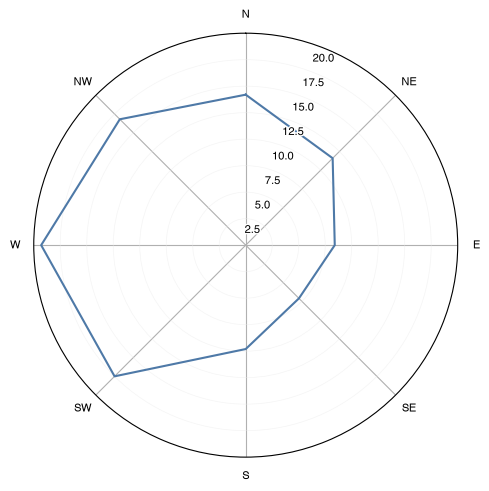

In [4]:
RadialChart(
    # add the data to the chart
    data=wind_by_direction
).show()

## Customizing the Radial Chart

Every customization is either a keyword argument of `RadialChart` or an attribute of its `style` dictionary; the style attributes follow the visual (`plot_line_*` and `plot_area_*` for the line, `plot_bar_*` for the bars, `plot_scatter_*` for the scatter, `plot_hist_*` for the histogram). The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                    | Use                                                                 | See |
| :-------------------------------------------- | :------------------------------------------------------------------ | :-- |
| pick the visual                               | `type`, `num_bins`                                                  | [The radial visuals](#the-radial-visuals) |
| add a title and axis labels                   | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and radial range](#title-axis-labels-and-radial-range) |
| fix the radial range                          | `ymin`, `ymax`                                                      | [Title, axis labels and radial range](#title-axis-labels-and-radial-range) |
| resize the figure                             | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| show the rings and spokes                     | `show_grid`                                                         | [Figure size and grid](#figure-size-and-grid) |
| rotate where the circle starts                | `startangle`                                                        | [Start angle and direction](#start-angle-and-direction) |
| flip the angular direction                    | `direction`                                                         | [Start angle and direction](#start-angle-and-direction) |
| cut a donut hole in the middle                | `innerradius`                                                       | [Inner radius](#inner-radius) |
| change the color, width, marker, or hatch     | `style={"plot_line_color": ..., "plot_bar_hatch": ...}`             | [Mark style](#mark-style) |
| highlight some bars, mute the rest            | `emphasis_rule`, the `"emphasis"` key of a data point               | [Sorting and emphasis](#sorting-and-emphasis) |
| order the sectors by value                    | `sort`, `sort_by`                                                   | [Sorting and emphasis](#sorting-and-emphasis) |
| print the value at each tip                   | `show_values`, `value_format`                                       | [Values and labels at the tips](#values-and-labels-at-the-tips) |
| move the category labels to the tips          | `show_tip_labels`                                                   | [Values and labels at the tips](#values-and-labels-at-the-tips) |
| hide the outer border circle                  | `show_border`                                                       | [Values and labels at the tips](#values-and-labels-at-the-tips) |
| shade a wedge or a ring                       | `vspans`, `hspans`                                                  | [Reference bands](#reference-bands) |
| put a note on the chart                       | `texts`                                                             | [Text annotations](#text-annotations) |
| compare several series in one chart           | `data` as a list of lists, `subtitle`, `show_legend`                | [Multiple Radial Charts](#multiple-radial-charts) |
| highlight one series, mute the rest           | `emphasis`                                                          | [Multiple Radial Charts](#multiple-radial-charts) |
| group, stack, or overlay the bar series       | `bar_mode`                                                          | [Bar mode](#bar-mode) |
| title and place the legend                    | `legend`                                                            | [Legend](#legend) |
| draw each series in its own subplot           | `subplots`, `sharex`, `sharey`, `max_cols`                          | [Subplots](#subplots) |
| draw an error band or fill the area           | `show_yerr`, `show_area`                                            | [Error bands and filled areas](#error-bands-and-filled-areas) |
| use a logarithmic radial axis                 | `scaley`                                                            | [Radial axis scale](#radial-axis-scale) |
| plot data with other key names                | `label`, `x`, `y`, `yerr`                                           | [Custom data keys](#custom-data-keys) |
| save the chart to a file                      | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `type` | [`RADIAL_TYPE`](../../../references/constants/#datachart.constants.RADIAL_TYPE) |
| `direction` | [`RADIAL_DIRECTION`](../../../references/constants/#datachart.constants.RADIAL_DIRECTION) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `bar_mode` | [`BAR_MODE`](../../../references/constants/#datachart.constants.BAR_MODE) |
| `sort` | [`SORT`](../../../references/constants/#datachart.constants.SORT) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |

The full lists of style attributes are in the [datachart.typings.LineStyleAttrs](../../../references/charts/linechart/#datachart.typings.LineStyleAttrs), [BarStyleAttrs](../../../references/charts/barchart/#datachart.typings.BarStyleAttrs), [ScatterStyleAttrs](../../../references/charts/scatterchart/#datachart.typings.ScatterStyleAttrs) and [HistStyleAttrs](../../../references/charts/histogram/#datachart.typings.HistStyleAttrs) types; the full list of parameters is in the [datachart.charts.RadialChart](../../../references/charts/radialchart/#datachart.charts.RadialChart) reference.

### The radial visuals

The first decision is which visual to draw, and the data answers it. `type` takes a [RADIAL_TYPE](../../../references/constants/#datachart.constants.RADIAL_TYPE) member:

- `RADIAL_TYPE.LINE` (the default) connects the values into a closed profile, the radar chart. Use it when the shape is the message: a few entities compared across several metrics on one scale, or a cycle whose continuity matters.
- `RADIAL_TYPE.BAR` draws one sector per category. Use it for one value per cyclic category (a month, an hour, a direction) when the sizes matter more than the shape; the sectors read like the hours on a clock face.
- `RADIAL_TYPE.SCATTER` draws one point per category. Use it when the values stand alone and connecting them would suggest a shape that is not there.
- `RADIAL_TYPE.HISTOGRAM` takes raw angular observations in degrees (an `x` key instead of `label` and `y`) and counts them in `num_bins` sectors around the full circle. Use it for a distribution of directions: the wind rose.

Monthly sunshine hours are one value per month, so they want bars: the long summer sectors at the bottom of the clock, the short winter ones at the top.

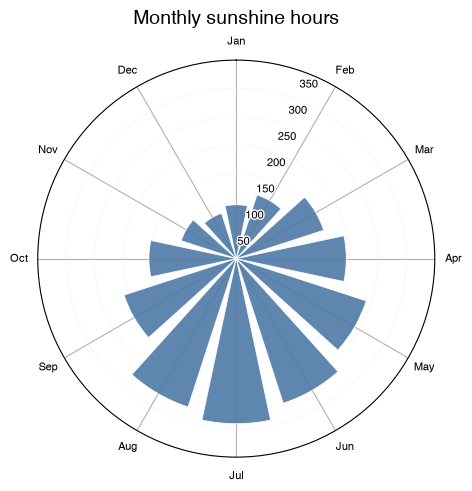

In [5]:
from datachart.constants import RADIAL_TYPE

RadialChart(
    data=sunshine_by_month,
    # one sector per month
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
).show()

The raw direction readings are a distribution, not one value per category, so they want the histogram. Binned into 16 sectors, they show where the wind comes from: mostly the south-west, with a second, smaller lobe from the north-east.

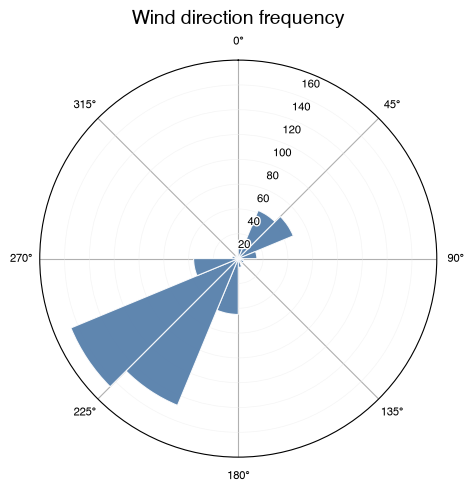

In [6]:
RadialChart(
    data=wind_directions,
    type=RADIAL_TYPE.HISTOGRAM,
    # count the readings in 16 sectors around the full circle
    num_bins=16,
    title="Wind direction frequency",
).show()

### Title, axis labels and radial range

A polar plot has two axes like any other chart, and the reader needs to know what each measures: `xlabel` names the angular axis (the categories around the circle), `ylabel` the radial axis (the values), and `title` says what the chart is about. `ymin` and `ymax` fix the radial range. Bars and areas measure from the center, so the radial axis should start at zero, and a `ymax` above the largest value leaves room for value labels added later.

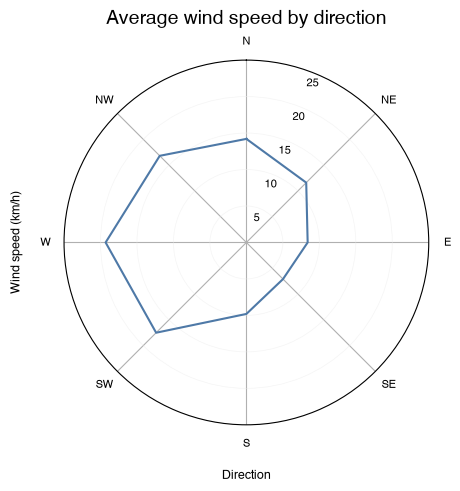

In [7]:
RadialChart(
    data=wind_by_direction,
    # add the title
    title="Average wind speed by direction",
    # name the angular and the radial axis
    xlabel="Direction",
    ylabel="Wind speed (km/h)",
    # fix the radial range
    ymin=0,
    ymax=25,
).show()

### Figure size and grid

A polar plot is round, so it wants a square figure, and a chart that goes into one column of a two-column page wants a small one. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE): `FIG_SIZE.SQUARE` for a standalone circle, `FIG_SIZE.HALF_SQUARE` for one column.

The grid of a polar plot is rings and spokes: the rings let the eye carry a bar tip to the radial ticks, the spokes separate the categories. A polar plot always draws both, and `show_grid` picks the ones drawn in the theme's soft grid style, with a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member: `Y` for the rings (the default), `X` for the spokes, `BOTH` for both; the others keep a darker grey. With `SHOW_GRID.BOTH` the spokes recede too, so the sectors stand out against a quiet background. The grid is always drawn below the marks, so a bar never hides behind a ring.

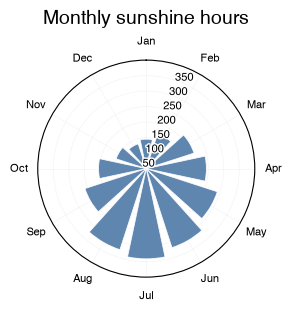

In [8]:
from datachart.constants import FIG_SIZE, SHOW_GRID

RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    # a small square figure for one column
    figsize=FIG_SIZE.HALF_SQUARE,
    # soft rings and soft spokes
    show_grid=SHOW_GRID.BOTH,
).show()

### Start angle and direction

Where the circle starts and which way it runs is a convention the reader brings along, and the chart should meet it. The default puts the first label at the top and runs clockwise, which is how a compass and a clock work, so directions and months read without instructions. `startangle` moves the first label: a compass point (`"N"`, `"NE"`, `"E"`, `"SE"`, `"S"`, `"SW"`, `"W"`, `"NW"`) or a bearing in degrees clockwise from the top. `direction` flips the way the angles increase, with a [RADIAL_DIRECTION](../../../references/constants/#datachart.constants.RADIAL_DIRECTION) member. Readers of scientific polar plots expect the mathematical convention instead, zero at the right and angles increasing counterclockwise; the example follows it, so January sits at the right and the year runs the other way round.

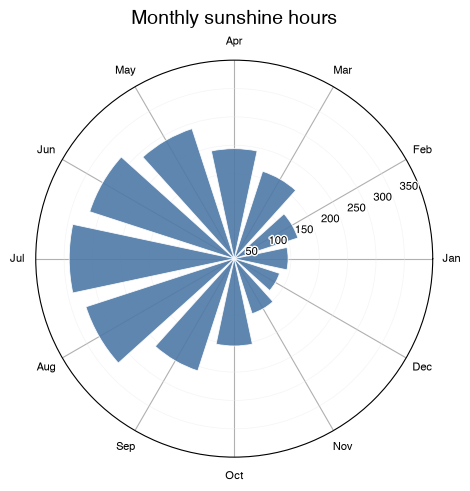

In [9]:
from datachart.constants import RADIAL_DIRECTION

RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    # the mathematical convention: start at the right, run counterclockwise
    startangle="E",
    direction=RADIAL_DIRECTION.COUNTERCLOCKWISE,
).show()

### Inner radius

Sectors that meet at the center shrink to slivers there, so the small values, and the bottom segments of stacked bars, are hard to read. `innerradius` cuts a donut hole, given as a fraction (between 0 and 1) of the radial extent: every bar starts at the hole instead of the center and keeps a readable width along its whole length. The short winter sectors, thin wedges near the center above, get a readable width with a quarter of the radius reserved for the hole.

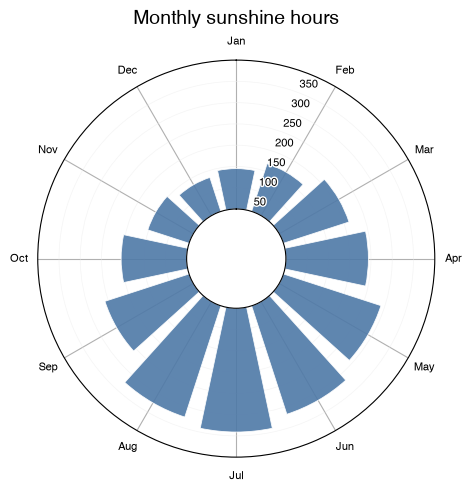

In [10]:
RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    # reserve the middle quarter of the radius for the hole
    innerradius=0.25,
).show()

### Mark style

The `style` dictionary sets the look of the marks, and a radial visual reads the same attributes as its cartesian counterpart: the line visual takes the `plot_line_*` and `plot_area_*` attributes of [LineStyleAttrs](../../../references/charts/linechart/#datachart.typings.LineStyleAttrs), the bars the `plot_bar_*` attributes of [BarStyleAttrs](../../../references/charts/barchart/#datachart.typings.BarStyleAttrs), and the scatter and histogram visuals the `plot_scatter_*` and `plot_hist_*` attributes. Any attribute left out keeps the value of the active theme, so [themes](../../styling/themes/) style radial charts like every other chart. A radar profile with eight vertices reads better when the vertices are marked: a marker from [LINE_MARKER](../../../references/constants/#datachart.constants.LINE_MARKER) puts a dot on each measured direction, and a dashed line from [LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE) says the segments between them are interpolation.

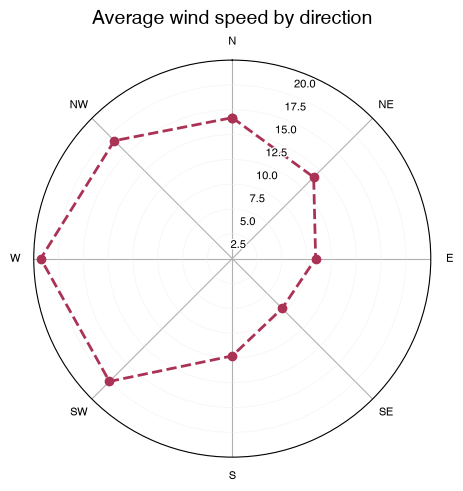

In [11]:
from datachart.constants import LINE_MARKER, LINE_STYLE

RadialChart(
    data=wind_by_direction,
    # the line visual takes the line chart's style attributes
    style={
        "plot_line_color": "#aa3355",
        "plot_line_width": 2,
        "plot_line_style": LINE_STYLE.DASHED,
        "plot_line_marker": LINE_MARKER.CIRCLE,
    },
    title="Average wind speed by direction",
    ymin=0,
).show()

### Sorting and emphasis

A chart usually makes one point. On the bar visual, `emphasis_rule` picks the bars that make it from the data: a one-key dictionary, `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}`; the matching bars are highlighted, the rest muted, and the values print on the highlighted bars only. A data point's own `"emphasis"` key (`"highlight"` or `"background"`, also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants) wins over the rule. The [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Asking which directions average above 15 km/h leaves three western sectors standing out of a grey compass.

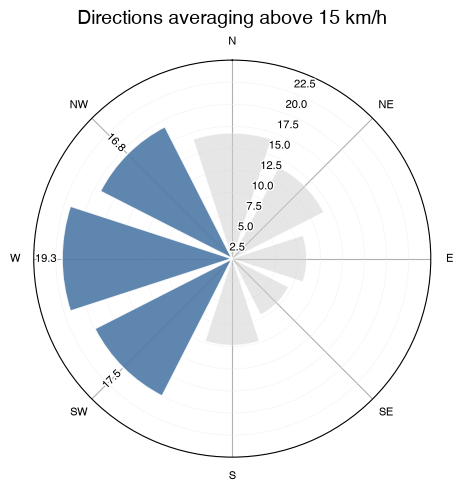

In [12]:
RadialChart(
    data=wind_by_direction,
    type=RADIAL_TYPE.BAR,
    title="Directions averaging above 15 km/h",
    # highlight the strong directions, mute the rest
    emphasis_rule={"above": 15},
    show_values=True,
    value_format="%.1f",
    ymin=0,
).show()

`sort` orders the sectors around the circle by value instead of by input order, with a [SORT](../../../references/constants/#datachart.constants.SORT) member: `SORT.DESCENDING` puts the largest sector first, at the start angle, `SORT.ASCENDING` the smallest. Sorting gives up the compass positions, so it answers a ranking question ("how do the directions rank by speed?") and not a directional one; the labels travel with their sectors, so nothing is lost. With several series one order serves all of them, keyed by the total across the series, or by the series named in `sort_by` (see [Bar mode](#bar-mode)).

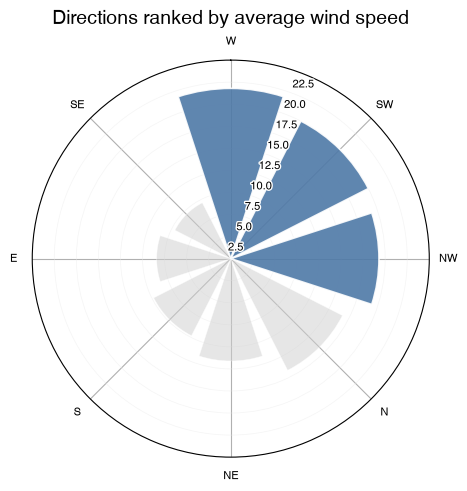

In [13]:
from datachart.constants import SORT

RadialChart(
    data=wind_by_direction,
    type=RADIAL_TYPE.BAR,
    title="Directions ranked by average wind speed",
    # the strongest direction first, clockwise from the top
    sort=SORT.DESCENDING,
    emphasis_rule={"above": 15},
    ymin=0,
).show()

### Values and labels at the tips

When the exact numbers matter, `show_values` prints each mark's value at its tip, rotated along its spoke, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or any `"{x:.1f}"` or `"%.1f"` style string. The label font size and color are the `plot_value_*` style attributes ([ValueLabelStyleAttrs](../../../references/typings/#datachart.typings.ValueLabelStyleAttrs)), shared by every chart that prints values.

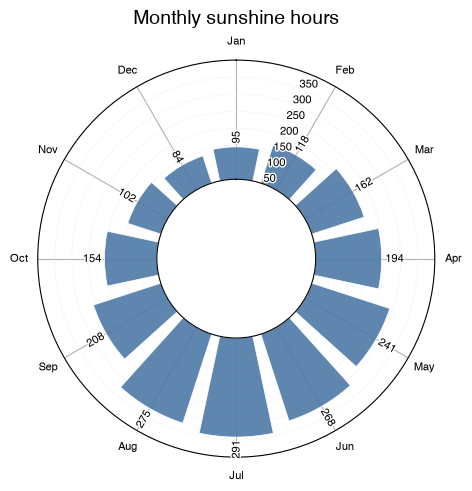

In [14]:
from datachart.constants import VALUE_FORMAT

RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    # a wider hole spreads the short winter labels apart
    innerradius=0.4,
    # print each month's hours at the tip of its bar
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
).show()

The category labels sit on a ring around the circle by default, at some distance from the bars they name. `show_tip_labels` moves them to the tips instead: each label hugs the outermost mark on its spoke and flips on the left half so it always reads outward. With `show_border=False`, which hides the outer circle, and a donut hole, this is the circular bar plot that reads at a glance from a slide.

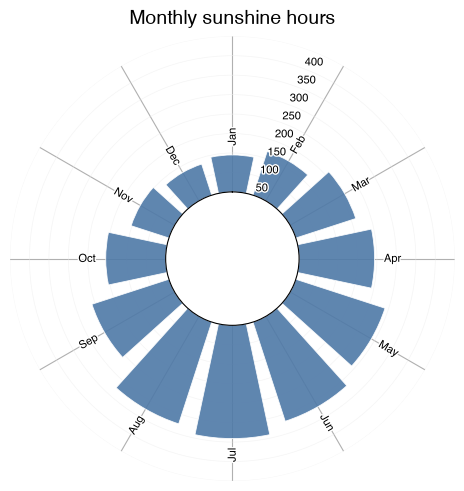

In [15]:
RadialChart(
    data=sunshine_by_month,
    type=RADIAL_TYPE.BAR,
    title="Monthly sunshine hours",
    innerradius=0.3,
    # the month names ride the bar tips, and the border circle goes
    show_tip_labels=True,
    show_border=False,
    figsize=FIG_SIZE.SQUARE,
).show()

### Reference bands

A straight reference line has no place on a circle, but a shaded band does. `vspans` shades an angular **wedge** over the full radius, bounded by `xmin` and `xmax` in degrees measured from the start angle in the chart's direction, so with the compass defaults `180` to `270` is the quadrant from south to west. `hspans` shades a **ring** over the full circle, bounded by `ymin` and `ymax` in radial values. Both take a dictionary or a list of them, with an optional `label` for the legend and a `style` with the `plot_vspan_*` or `plot_hspan_*` attributes ([VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs), [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs)); an omitted bound runs to the edge. The example shades the quadrant the strongest winds come from and the speed range of a gentle breeze (about 12 to 20 km/h, force 3 on the Beaufort scale), with `ymax` above it so the ring ends inside the border.

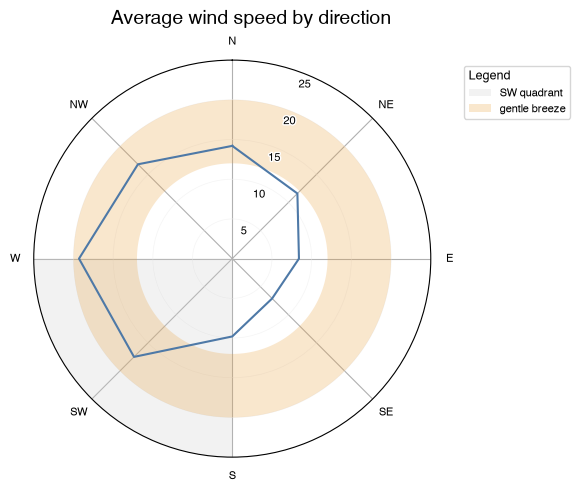

In [16]:
from datachart.constants import LEGEND_LOCATION

RadialChart(
    data=wind_by_direction,
    # a wedge from south (180°) to west (270°)
    vspans={"xmin": 180, "xmax": 270, "label": "SW quadrant"},
    # a ring between 12 and 20 km/h
    hspans={
        "ymin": 12,
        "ymax": 20,
        "label": "gentle breeze",
        "style": {"plot_hspan_color": "#e9a03b"},
    },
    title="Average wind speed by direction",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    ymin=0,
    ymax=25,
).show()

### Text annotations

Where a band marks a range, a note explains a point. `texts` places text on the chart, with an optional `target` to draw a connector to a mark. Data coordinates on a polar axes are (angle in radians, radius), with the angle counted from the start angle in the chart's direction, so the west value of an eight-point compass sits at 270°. Axes fractions (`"coords": "axes"`) are the other option, for a note in a corner; here the note sits inside the profile, on the west spoke, and points outward at the value. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling.

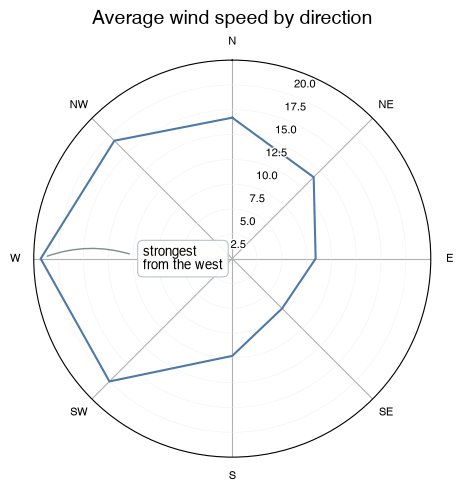

In [17]:
import math

RadialChart(
    data=wind_by_direction,
    # a note on the west spoke (angle in radians, radius), pointing at the value
    texts={
        "text": "strongest\nfrom the west",
        "x": math.radians(270),
        "y": 9,
        "target": (math.radians(270), SPEED[COMPASS.index("W")]),
    },
    title="Average wind speed by direction",
    ymin=0,
).show()

## Multiple Radial Charts

To compare several series, pass a list of lists to `data`: each inner list is one series, all drawn with the figure's one `type`, and the per-series attributes (`subtitle`, `style`, `emphasis`) become lists aligned with it. `show_legend` names the series by their subtitles. `wind_last_year`, defined in a hidden cell, holds the same station's averages of the year before, and two radar profiles on one circle show where the wind picked up: the western directions grew, the north-east barely moved.

In [18]:
# the average wind speed (km/h) per direction in the year before
wind_last_year = [
    {"label": d, "y": s}
    for d, s in zip(COMPASS, [12.8, 12.9, 9.6, 8.2, 8.9, 15.1, 17.2, 15.3])
]
wind_this_year = [{"label": p["label"], "y": p["y"]} for p in wind_by_direction]

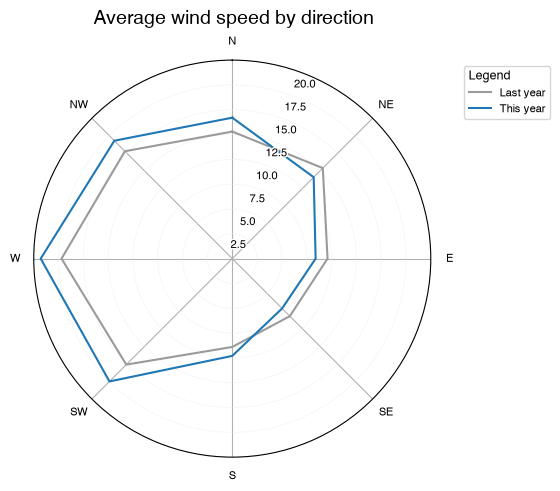

In [19]:
RadialChart(
    # one series per year
    data=[wind_last_year, wind_this_year],
    # named for the legend
    subtitle=["Last year", "This year"],
    # last year in grey, this year in color
    style=[{"plot_line_color": "#9a9a9a"}, {"plot_line_color": "#1f77b4"}],
    title="Average wind speed by direction",
    show_legend=True,
    # outside the circle, clear of the category labels
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    ymin=0,
).show()

When the question is about one of the series, `emphasis` takes one role per series, aligned with `data` like `subtitle` and `style`: `"highlight"` bolds a series and brings it to the front, `"background"` mutes it and drops it from the legend, `None` leaves it as it is. This year is the story; last year becomes the context:

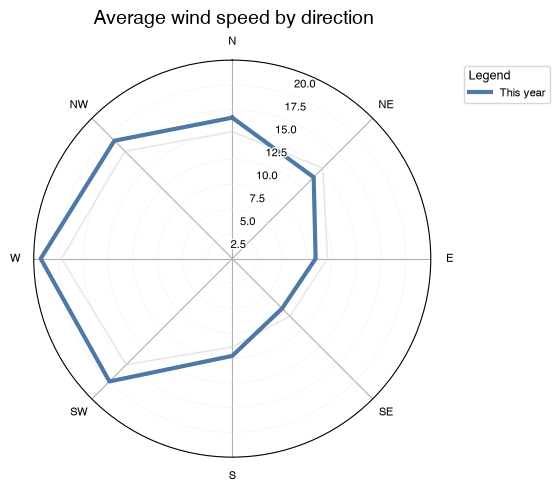

In [20]:
RadialChart(
    data=[wind_last_year, wind_this_year],
    subtitle=["Last year", "This year"],
    # mute last year, highlight this year
    emphasis=["background", "highlight"],
    title="Average wind speed by direction",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    ymin=0,
).show()

### Bar mode

Several bar series share each sector the way cartesian bars share a category, and `bar_mode` says how, with a [BAR_MODE](../../../references/constants/#datachart.constants.BAR_MODE) member: `BAR_MODE.GROUP` (the default) puts them side by side within the sector, `BAR_MODE.STACK` stacks them, so the outer edge is the total and the segments its split, and `BAR_MODE.OVERLAY` draws them at the same position, one over the other. `morning` and `afternoon`, defined in a hidden cell, split each month's sunshine into the hours before and after noon; stacked, they keep the monthly total readable and show the afternoon's larger share.

In [21]:
# monthly sunshine hours split into the hours before and after noon
morning = [{"label": p["label"], "y": round(p["y"] * 0.42)} for p in sunshine_by_month]
afternoon = [{"label": p["label"], "y": p["y"] - m["y"]} for p, m in zip(sunshine_by_month, morning)]

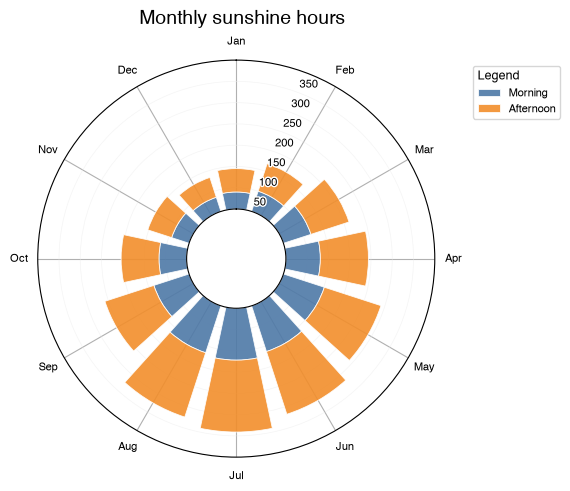

In [22]:
from datachart.constants import BAR_MODE

RadialChart(
    data=[morning, afternoon],
    type=RADIAL_TYPE.BAR,
    subtitle=["Morning", "Afternoon"],
    # stack the two halves of the day in each sector
    bar_mode=BAR_MODE.STACK,
    title="Monthly sunshine hours",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    innerradius=0.25,
).show()

With several series, `sort` orders the sectors by the total across them, and `sort_by` names the series (by its `subtitle`) that keys the order instead. Ranked by the afternoon hours alone, the months come out in the order of their afternoons, July first:

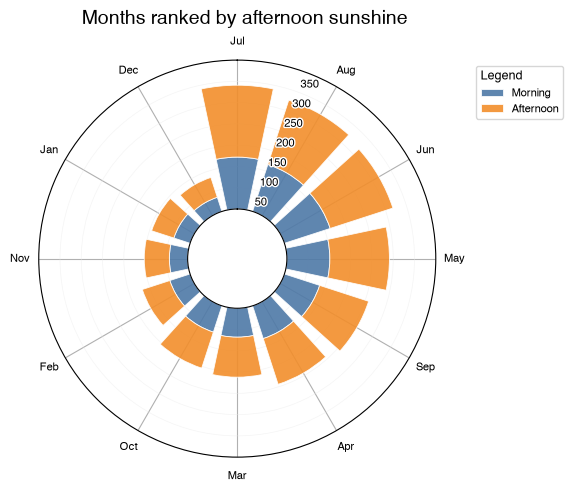

In [23]:
RadialChart(
    data=[morning, afternoon],
    type=RADIAL_TYPE.BAR,
    subtitle=["Morning", "Afternoon"],
    bar_mode=BAR_MODE.STACK,
    title="Months ranked by afternoon sunshine",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    innerradius=0.25,
    # one order for both series, keyed by one of them
    sort=SORT.DESCENDING,
    sort_by="Afternoon",
).show()

### Legend

`show_legend` lists the series; `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). The default corner of the axes is where the category labels of a polar plot sit, so a legend there covers one of them; the examples above use `LEGEND_LOCATION.OUTSIDE_RIGHT` to keep it clear of the circle. Below the circle, a title and two columns turn the legend into one tidy row.

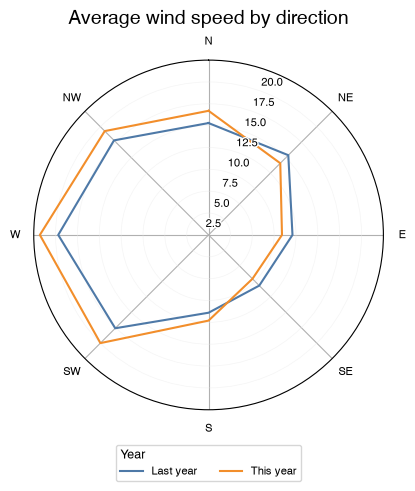

In [24]:
RadialChart(
    data=[wind_last_year, wind_this_year],
    subtitle=["Last year", "This year"],
    title="Average wind speed by direction",
    show_legend=True,
    # a titled, two-column legend below the circle
    legend={"title": "Year", "location": LEGEND_LOCATION.OUTSIDE_BOTTOM, "ncols": 2},
    ymin=0,
).show()

### Subplots

When the profiles are many, or two of them overlap so much that one circle turns into a tangle, `subplots=True` draws each series in its own polar subplot. `subtitle` titles the panels, `title` stays global, and `max_cols` limits the panels per row. `sharey=True` gives every panel the same radial range, so a profile in one panel is comparable with a profile in the next; without it each panel scales to its own maximum and last year's smaller profile would look as large as this year's. `sharex=True` keeps one angular axis for all of them.

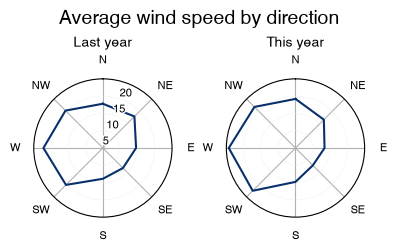

In [25]:
RadialChart(
    data=[wind_last_year, wind_this_year],
    subtitle=["Last year", "This year"],
    title="Average wind speed by direction",
    figsize=FIG_SIZE.FULL_SHORT,
    # one polar panel per year, side by side
    subplots=True,
    max_cols=2,
    # the same radial range for both panels
    sharey=True,
    ymin=0,
).show()

## Additional Features

### Error bands and filled areas

The line visual takes the enrichments of the line chart. An average hides the spread behind it: `show_yerr=True` draws a band of `yerr` around the line, so the gusty western directions show a wide band and the calm eastern ones a narrow one. The band, like the area below, uses the `plot_area_*` style attributes.

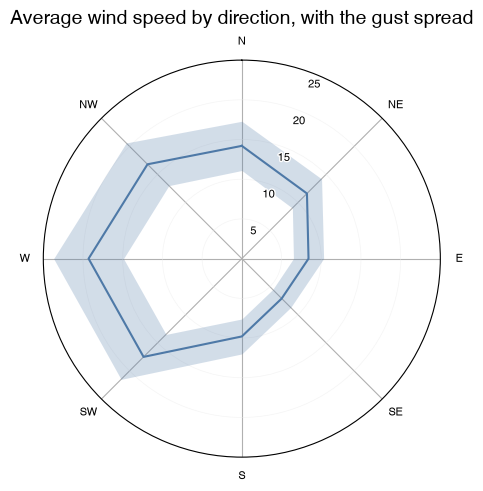

In [26]:
RadialChart(
    data=wind_by_direction,
    # the gust standard deviation as a band around the line
    show_yerr=True,
    title="Average wind speed by direction, with the gust spread",
    ymin=0,
).show()

`show_area=True` fills the polygon the line encloses, which turns a profile into a footprint: the area says how much wind there is over all directions at once, and two filled profiles compare as shapes rather than as lines.

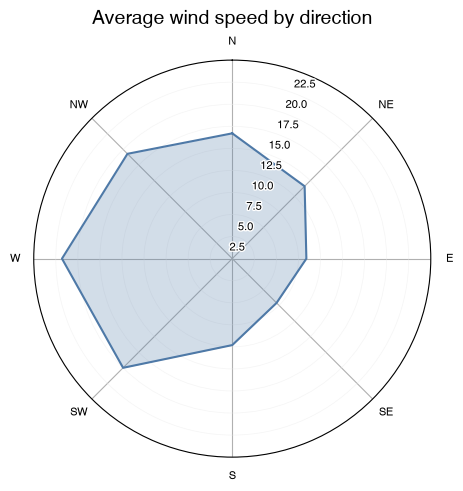

In [27]:
RadialChart(
    data=wind_by_direction,
    # fill the polygon the line encloses
    show_area=True,
    title="Average wind speed by direction",
    ymin=0,
).show()

### Radial axis scale

The radial axis is a value axis, and `scaley` changes its scale with a [SCALE](../../../references/constants/#datachart.constants.SCALE) member, like the y-axis of a cartesian chart; the angular axis has no scale. A logarithmic radius is for values that span orders of magnitude around the cycle. `lightning_by_month`, defined in a hidden cell, holds the illustrative monthly count of lightning strikes recorded by the station, from a handful in winter to thousands in summer. On a linear radius the winter months would sit on the center; on a log radius starting at `ymin=1` every month is readable. The scatter visual fits here: each count is a point that stands alone, and a line through them would draw a shape that is mostly the scale.

In [28]:
# illustrative monthly count of lightning strikes recorded by the station
LIGHTNING = [4, 6, 30, 180, 900, 2400, 3100, 2200, 600, 90, 12, 5]
lightning_by_month = [{"label": m, "y": n} for m, n in zip(MONTHS, LIGHTNING)]

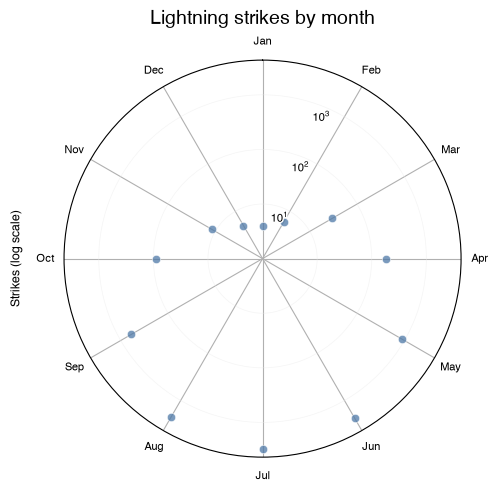

In [29]:
from datachart.constants import SCALE

RadialChart(
    data=lightning_by_month,
    type=RADIAL_TYPE.SCATTER,
    # a log radius: from a handful to thousands on one circle
    scaley=SCALE.LOG,
    # start the radius at one strike, so the winter counts leave the center
    ymin=1,
    title="Lightning strikes by month",
    ylabel="Strikes (log scale)",
).show()

### Custom data keys

Data that comes from a file or an API rarely uses the `label`, `y`, `yerr` and `x` keys, and renaming every record just to plot it is a chore. Instead, tell `RadialChart` which keys to read with the `label`, `y`, `yerr` and `x` arguments (`x` names the key holding the degree readings of the histogram visual). `station_records` stores the wind table the way a CSV export would, one record per direction with a `direction`, a `speed` and a `gust_sd` key:

In [30]:
station_records = [
    {"direction": d, "speed": s, "gust_sd": g} for d, s, g in zip(COMPASS, SPEED, GUST_STD)
]
station_records[:2]

[{'direction': 'N', 'speed': 14.2, 'gust_sd': 3.1},
 {'direction': 'NE', 'speed': 11.6, 'gust_sd': 2.6}]

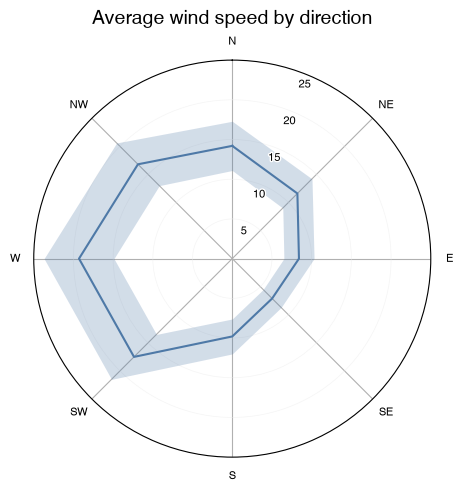

In [31]:
RadialChart(
    data=station_records,
    # the keys that hold the label, the value and the error
    label="direction",
    y="speed",
    yerr="gust_sd",
    show_yerr=True,
    title="Average wind speed by direction",
    ymin=0,
).show()

## Real-World Examples

The examples below put the features above to work, each one answering a question with the visual that fits it. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Does the Wind Turn with the Season? (Angular Histograms in a Grid)

`winter_directions` and `summer_directions` hold illustrative wind direction readings of the station for the two seasons, drawn from a seeded generator: a coast where the winter storms come from the south-west and a summer sea breeze sets in from the south-east. The question is about a distribution of directions, so each season gets a wind rose (the histogram visual with 16 sectors), and the two roses go side by side in a [Grid](../../utility/grid/) with the same radial range, so the sizes of the lobes compare across the seasons and not just their directions.

In [32]:
# illustrative wind direction readings of the station in the two seasons
rng = np.random.RandomState(7)
WINTER = np.concatenate([rng.normal(225, 22, 260), rng.uniform(0, 360, 40)])
SUMMER = np.concatenate([rng.normal(135, 15, 170), rng.normal(225, 25, 80), rng.uniform(0, 360, 50)])
winter_directions = [{"x": float(deg % 360)} for deg in WINTER]
summer_directions = [{"x": float(deg % 360)} for deg in SUMMER]

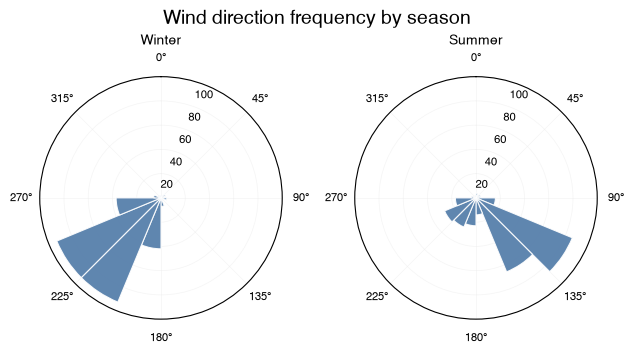

In [33]:
from datachart.utils import Grid


def wind_rose(data, season):
    # a wind rose with 16 sectors on a shared radial range
    return RadialChart(
        data=data,
        type=RADIAL_TYPE.HISTOGRAM,
        num_bins=16,
        title=season,
        show_grid=SHOW_GRID.BOTH,
        ymin=0,
        ymax=100,
    )


Grid(
    [[wind_rose(winter_directions, "Winter"), wind_rose(summer_directions, "Summer")]],
    title="Wind direction frequency by season",
    figsize=(6.3, 3.4),
).show()

### Example 2: Which Candidate Fits the Role? (Radar Profiles with Areas and a Requirement)

`role_profile`, `candidate_a` and `candidate_b` hold illustrative interview scores on six skills, on a 0 to 10 scale, and the minimum the role requires on each. The question compares two entities across several metrics on one scale, which is what the radar form is for: `show_area` turns each profile into a footprint, and a fixed radial range of 0 to 10 keeps the scale honest. The requirement is drawn as a dashed profile without an area, so wherever a candidate's footprint stays inside the dashed line, that candidate falls short: A on databases, B on visualization.

In [34]:
# illustrative interview scores on a 0-10 scale, and the minimum the role requires
SKILLS = ["Python", "Statistics", "Visualization", "ML", "Databases", "Communication"]
role_profile = [{"label": s, "y": y} for s, y in zip(SKILLS, [7, 6, 7, 5, 6, 6])]
candidate_a = [{"label": s, "y": y} for s, y in zip(SKILLS, [9, 7, 8, 6, 4, 8])]
candidate_b = [{"label": s, "y": y} for s, y in zip(SKILLS, [7, 8, 5, 9, 8, 6])]

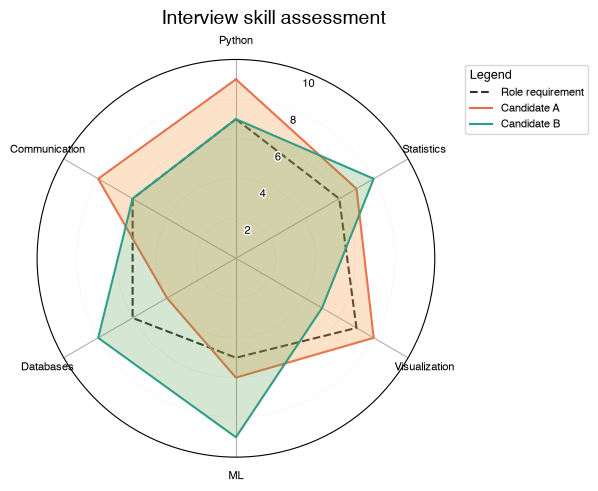

In [35]:
RadialChart(
    data=[role_profile, candidate_a, candidate_b],
    subtitle=["Role requirement", "Candidate A", "Candidate B"],
    style=[
        # the requirement: a dashed dark outline and no footprint
        {"plot_line_color": "#333333", "plot_line_style": LINE_STYLE.DASHED, "plot_area_alpha": 0},
        {"plot_line_color": "#e76f51"},
        {"plot_line_color": "#2a9d8f"},
    ],
    # filled footprints on a fixed 0-10 scale
    show_area=True,
    ymin=0,
    ymax=10,
    title="Interview skill assessment",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: Was This Season Busier Than Last? (Stacked Donut Bars and a Panel)

`weekday_visits` and `weekend_visits` hold illustrative monthly visitor counts at a mountain hut, split by weekdays and weekends, and `visits_last_year` the monthly totals of the year before. Months around a circle read like a calendar clock, and the hut's season is one long summer swing on it. The two splits are stacked bars with a donut hole, so the outer edge of each stack is the month's total; last year's totals are the comparison, drawn as a line over the same scale. `RadialChart` draws one visual per figure, so the bars and the line are two figures overlaid with [Panel](../../utility/panel/), which keeps the first figure's start angle and donut hole. The panel owns how bars share a sector, so `bar_mode` is passed to `Panel` as well. Wherever the line pokes out of the bars, last year was busier: September, and nowhere else.

In [36]:
# illustrative monthly visitors at a mountain hut: this year by weekday and weekend, and last year's totals
WEEKDAY = [180, 210, 380, 690, 1150, 1580, 1920, 1860, 1240, 760, 320, 200]
WEEKEND = [340, 390, 640, 1050, 1710, 2260, 2840, 2750, 1880, 1170, 520, 380]
LAST_YEAR = [470, 550, 930, 1600, 2680, 3610, 4450, 4360, 3350, 1780, 780, 530]
weekday_visits = [{"label": m, "y": v} for m, v in zip(MONTHS, WEEKDAY)]
weekend_visits = [{"label": m, "y": v} for m, v in zip(MONTHS, WEEKEND)]
visits_last_year = [{"label": m, "y": v} for m, v in zip(MONTHS, LAST_YEAR)]

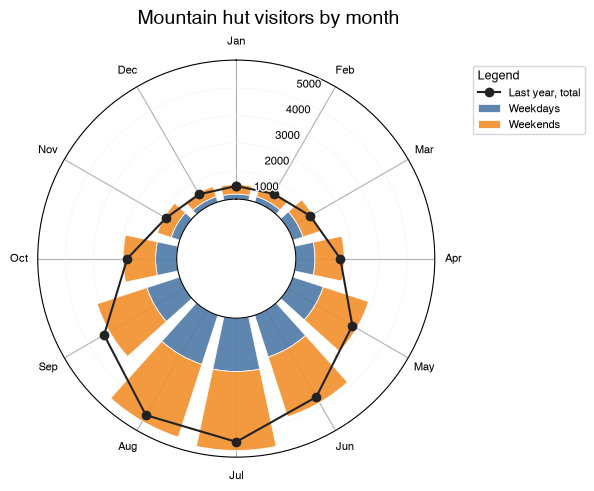

In [37]:
from datachart.utils import Panel

this_year = RadialChart(
    data=[weekday_visits, weekend_visits],
    type=RADIAL_TYPE.BAR,
    subtitle=["Weekdays", "Weekends"],
    # stacked, so the outer edge is the month's total
    bar_mode=BAR_MODE.STACK,
    innerradius=0.3,
)
last_year = RadialChart(
    data=visits_last_year,
    subtitle="Last year, total",
    style={"plot_line_color": "#222222", "plot_line_marker": LINE_MARKER.CIRCLE},
)

Panel(
    # the bars first: the panel keeps their donut hole
    [this_year, last_year],
    # the panel stacks the bar series too
    bar_mode=BAR_MODE.STACK,
    title="Mountain hut visitors by month",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()